In [2]:
import pandas as pd
import numpy as np

In [2]:
url = 'https://www.ispdados.rj.gov.br/Arquivos/BaseDPEvolucaoMensalCisp.csv'
df = pd.read_csv(url, encoding= 'latin1', sep=';')
df.head(3)


,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,NaN,NaN,21,2,0,0,0,0,578,3
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,15,6,0,1,0,0,441,3
2,5,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,47,2,1,0,0,0,637,3


In [3]:
df.tail(2)

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
38134,167,7,2026,2026m07,43,5,Paraty,3303807,Capital,1,...,3.0,0.0,27,2,1,0,0,0,206,2
38135,168,7,2026,2026m07,28,5,Rio Claro,3304409,Interior,0,...,0.0,0.0,4,2,0,0,0,0,52,2


In [4]:
df.columns

Index(['cisp', 'mes', 'ano', 'mes_ano', 'aisp', 'risp', 'munic', 'mcirc',
       'regiao', 'hom_doloso', 'lesao_corp_morte', 'latrocinio', 'cvli',
       'hom_por_interv_policial', 'feminicidio', 'letalidade_violenta',
       'tentat_hom', 'tentativa_feminicidio', 'lesao_corp_dolosa', 'estupro',
       'hom_culposo', 'lesao_corp_culposa', 'roubo_transeunte',
       'roubo_celular', 'roubo_em_coletivo', 'roubo_rua', 'roubo_veiculo',
       'roubo_carga', 'roubo_comercio', 'roubo_residencia', 'roubo_banco',
       'roubo_cx_eletronico', 'roubo_conducao_saque', 'roubo_apos_saque',
       'roubo_bicicleta', 'outros_roubos', 'total_roubos', 'furto_veiculos',
       'furto_transeunte', 'furto_coletivo', 'furto_celular',
       'furto_bicicleta', 'outros_furtos', 'total_furtos', 'sequestro',
       'extorsao', 'sequestro_relampago', 'estelionato', 'apreensao_drogas',
       'posse_drogas', 'trafico_drogas', 'apreensao_drogas_sem_autor',
       'recuperacao_veiculos', 'apf', 'aaapai', 'cmp', '

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38136 entries, 0 to 38135
Data columns (total 65 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cisp                        38136 non-null  int64  
 1   mes                         38136 non-null  int64  
 2   ano                         38136 non-null  int64  
 3   mes_ano                     38136 non-null  str    
 4   aisp                        38136 non-null  int64  
 5   risp                        38136 non-null  int64  
 6   munic                       38136 non-null  str    
 7   mcirc                       38136 non-null  int64  
 8   regiao                      38136 non-null  str    
 9   hom_doloso                  38136 non-null  int64  
 10  lesao_corp_morte            38136 non-null  int64  
 11  latrocinio                  38136 non-null  int64  
 12  cvli                        38136 non-null  int64  
 13  hom_por_interv_policial     38136 non-null

In [6]:
df.head(2)

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,NaN,NaN,21,2,0,0,0,0,578,3
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,15,6,0,1,0,0,441,3


In [7]:
df_furto_cel_dp = df.groupby('cisp')['furto_celular'].sum().reset_index()
df_furto_cel_dp = df_furto_cel_dp.sort_values(by='furto_celular', ascending = False)
df_furto_cel_dp

,cisp,furto_celular
12,16,26230
2,5,25737
10,14,19004
8,12,17630
0,1,16185
...,...,...
41,45,73
77,92,65
114,138,56
131,157,55


In [8]:
df_roubo_rua_dp = df.groupby('cisp')['roubo_rua'].sum().reset_index()
df_roubo_rua_dp = df_roubo_rua_dp.sort_values(by='roubo_rua', ascending = False)
df_roubo_rua_dp

,cisp,roubo_rua
52,59,87977
57,64,64885
30,34,58399
25,29,50260
65,74,47624
...,...,...
131,157,16
130,156,11
94,111,7
77,92,6


In [9]:
array_roubo_rua_dp = np.array(df_roubo_rua_dp['roubo_rua'])

In [10]:

media = np.mean(array_roubo_rua_dp)
mediana = np.median(array_roubo_rua_dp)
q1 = np.percentile(array_roubo_rua_dp, 25)
q2 = np.percentile(array_roubo_rua_dp, 50)
q3 = np.percentile(array_roubo_rua_dp,75)


In [11]:
print (f'Média {media}\nMediana {mediana}\nQ1 {q1}\nQ2 {q2}\nQ3 {q3}')


Média 13063.54347826087
Mediana 5340.5
Q1 253.5
Q2 5340.5
Q3 23459.5


In [12]:
distancia = (media - mediana) / mediana
print(distancia)
print(f'{distancia:.2%}')

1.4461274184553636
144.61%


In [13]:
df_aaapai_dp = df.groupby('cisp')['aaapai'].sum().reset_index()
df_aaapai_dp = df_aaapai_dp.sort_values(by='aaapai', ascending = False)
df_aaapai_dp

,cisp,aaapai
104,126,3736.0
8,12,3667.0
10,14,3368.0
65,74,3355.0
12,16,3233.0
...,...,...
130,156,19.0
129,155,16.0
131,157,14.0
94,111,13.0


In [14]:
df_roubo_veiculo_dp = df.groupby('cisp')['roubo_veiculo'].sum().reset_index()
df_roubo_veiculo_dp = df_roubo_veiculo_dp.sort_values(by='roubo_veiculo', ascending = False)
df_roubo_veiculo_dp

,cisp,roubo_veiculo
52,59,37866
57,64,32892
35,39,29753
23,27,27978
30,34,27596
...,...,...
77,92,8
116,140,8
115,139,7
113,137,6


In [15]:
df_capital = df[df['munic'] == 'Rio de Janeiro'] #usando sistema de filtro, assim seria na unha. dfdentro de munic só quero rio de janeiro
df_capital

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,NaN,NaN,21,2,0,0,0,0,578,3
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,15,6,0,1,0,0,441,3
2,5,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,47,2,1,0,0,0,637,3
3,6,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,NaN,NaN,26,2,1,0,0,0,473,3
4,7,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,NaN,NaN,10,1,3,0,0,0,147,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38035,40,7,2026,2026m07,9,2,Rio de Janeiro,3304557,Capital,0,...,4.0,1.0,20,1,0,0,0,0,576,2
38036,41,7,2026,2026m07,18,2,Rio de Janeiro,3304557,Capital,2,...,6.0,1.0,33,2,1,0,0,0,767,2
38037,42,7,2026,2026m07,31,2,Rio de Janeiro,3304557,Capital,4,...,16.0,2.0,135,11,0,0,0,0,1569,2
38038,43,7,2026,2026m07,27,2,Rio de Janeiro,3304557,Capital,2,...,5.0,2.0,93,3,0,0,0,0,736,2


In [16]:
df

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,NaN,NaN,21,2,0,0,0,0,578,3
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,15,6,0,1,0,0,441,3
2,5,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,47,2,1,0,0,0,637,3
3,6,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,NaN,NaN,26,2,1,0,0,0,473,3
4,7,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,NaN,NaN,10,1,3,0,0,0,147,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38131,159,7,2026,2026m07,11,7,Cachoeiras de Macacu,3300803,Interior,0,...,3.0,0.0,21,3,0,0,0,0,148,2
38132,165,7,2026,2026m07,33,5,Mangaratiba,3302601,Interior,2,...,8.0,0.0,40,1,0,0,0,0,180,2
38133,166,7,2026,2026m07,33,5,Angra dos Reis,3300100,Interior,3,...,21.0,3.0,96,4,0,0,0,0,710,2
38134,167,7,2026,2026m07,43,5,Paraty,3303807,Capital,1,...,3.0,0.0,27,2,1,0,0,0,206,2


In [17]:
df_capital = df.loc[df['munic'] == 'Rio de Janeiro']

#usando .query() - sintaxw alternativa mais legível
df_capital = df.query("munic == 'Rio de Janeiro'")

df_furto_cel_dp_capital = df_capital.groupby('cisp')['furto_celular'].sum().reset_index()
df_furto_cel_dp_capital = df_furto_cel_dp_capital.sort_values(by='furto_celular', ascending=False)
df_furto_cel_dp_capital 



,cisp,furto_celular
12,16,26230
2,5,25737
10,14,19004
8,12,17630
0,1,16185
5,9,15367
6,10,14842
14,18,14504
1,4,14339
28,32,12898


In [18]:
munic_pedido = ['Belford Roxo', 'Nova Iguaçu', 'Queimados']

df_bel_nov_quei = df.loc[df["munic"].isin(munic_pedido) & (df['ano'] == 2025)] #fez a lista com munícipio para filtar eses 3 munic data frame.locdf procurar em munic dentro de munic pedido isin, dentro de, & add filtro ano.

df_furto_cel_dp_belford = df_bel_nov_quei.groupby('cisp')['furto_celular'].sum().reset_index()
df_furto_cel_dp_belford = df_furto_cel_dp_belford.sort_values(by='furto_celular', ascending=False)
df_furto_cel_dp_belford

,cisp,furto_celular
0,52,519
4,58,188
3,56,123
1,54,112
2,55,96


In [19]:
array_furto_cel_dp = np.array(df_furto_cel_dp['furto_celular'])
array_furto_cel_dp

array([26230, 25737, 19004, 17630, 16185, 15367, 14842, 14504, 14339,
       12898, 12278,  8952,  8882,  8754,  8377,  8301,  8192,  7865,
        7388,  7344,  7074,  6991,  6691,  6657,  6218,  5793,  5692,
        5625,  5464,  5389,  5070,  4988,  4776,  4768,  4723,  4680,
        4193,  4150,  4140,  4059,  3891,  3853,  3798,  3770,  3552,
        3435,  3381,  3301,  3165,  3014,  2992,  2879,  2829,  2726,
        2618,  2418,  2398,  2366,  2335,  2219,  2168,  2154,  2145,
        2138,  2097,  1845,  1844,  1831,  1763,  1720,  1670,  1638,
        1554,  1488,  1476,  1446,  1394,  1386,  1311,  1250,  1154,
        1096,  1053,  1044,  1041,   941,   836,   824,   812,   752,
         745,   663,   662,   637,   634,   627,   585,   569,   517,
         516,   507,   501,   464,   453,   451,   443,   414,   405,
         387,   376,   369,   362,   357,   304,   303,   261,   245,
         241,   214,   206,   203,   198,   174,   167,   157,   148,
         129,   126,

In [20]:
minimo = np.min(array_furto_cel_dp)
maximo = np.max(array_furto_cel_dp)
amplitude = maximo - minimo
media = np.mean(array_furto_cel_dp)
mediana = np.median(array_furto_cel_dp)
q1 = np.percentile(array_furto_cel_dp, 25)
q2 = np.percentile(array_furto_cel_dp, 50)
q3 = np.percentile(array_furto_cel_dp,75)
iqr = q3 - q1
limite_superior = q3 + (1.5 * iqr)
limite_inferior = q1 - (1.5 * iqr)

print (f'Mínimo {minimo}')
print (f'Máximo {maximo}')
print (f'Amplitude {amplitude}')
print (f'Q1 {q1}')
print (f'Q2 {q2}')
print (f'Q3 {q3}')
print (f'Média {media}')
print (f'Mediana {mediana}')
print (f'Distancia {distancia:.2%}')
print(f'Limite Superior {limite_superior}')
print(f'Limite Inferior {limite_inferior}')


Mínimo 47
Máximo 26230
Amplitude 26183
Q1 455.75
Q2 1741.5
Q3 4712.25
Média 3554.4347826086955
Mediana 1741.5
Distancia 144.61%
Limite Superior 11097.0
Limite Inferior -5929.0


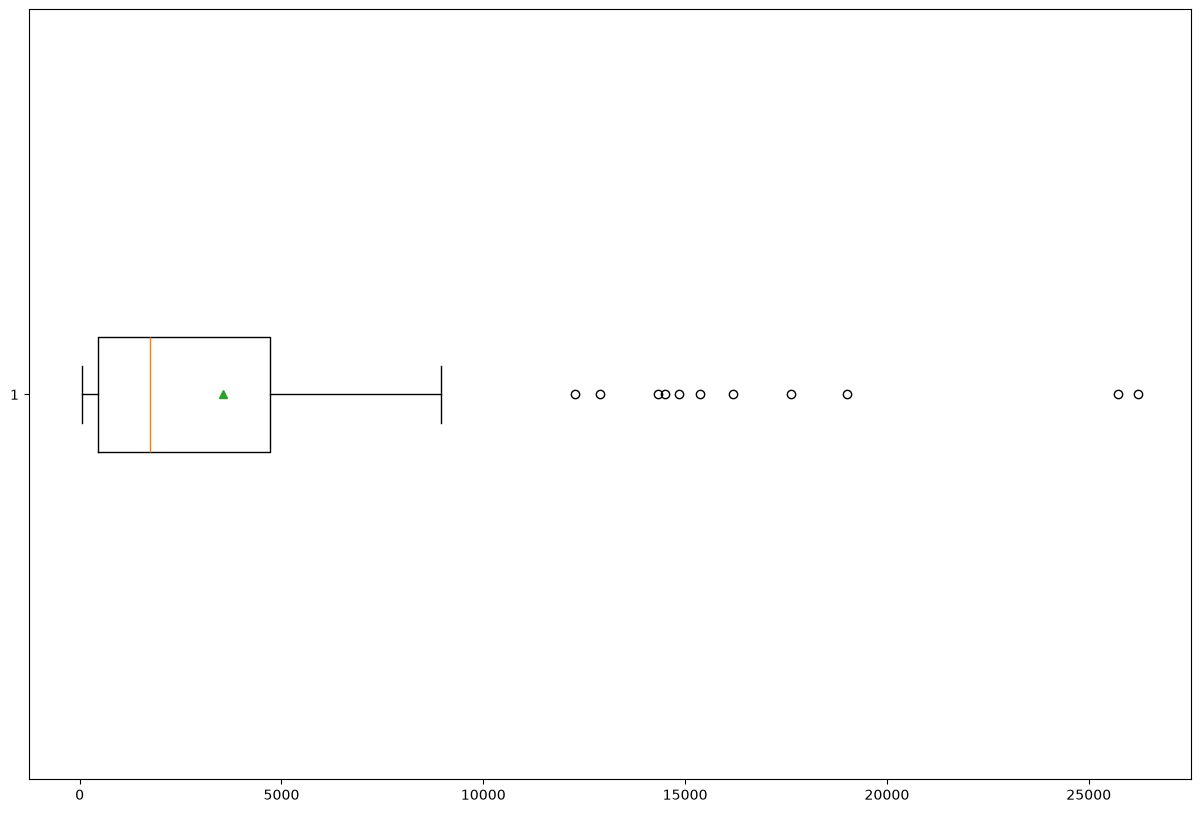

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plt.boxplot(array_furto_cel_dp, orientation='horizontal', showmeans=True)
plt.show()

In [22]:
outlier_furto_cel_dp = df_furto_cel_dp.loc[df_furto_cel_dp['furto_celular'] > limite_superior]

outlier_furto_cel_dp

,cisp,furto_celular
12,16,26230
2,5,25737
10,14,19004
8,12,17630
0,1,16185
5,9,15367
6,10,14842
14,18,14504
1,4,14339
28,32,12898


In [23]:
print(f'Media {media}')
print(f'Mediana {mediana}')
print(f'Q1: {q1}')
print(f'Q2: {q2}')
print(f'Q3: {q3}')

Media 3554.4347826086955
Mediana 1741.5
Q1: 455.75
Q2: 1741.5
Q3: 4712.25


In [24]:
df_furto_cel_acima_q3 = df_furto_cel_dp.loc[df_furto_cel_dp['furto_celular'] > q3]
df_furto_cel_acima_q3

,cisp,furto_celular
12,16,26230
2,5,25737
10,14,19004
8,12,17630
0,1,16185
5,9,15367
6,10,14842
14,18,14504
1,4,14339
28,32,12898


In [25]:
df_roubo_veiculo_dp = df.groupby('cisp')['roubo_veiculo'].sum().reset_index()
df_roubo_veiculo_dp = df_roubo_veiculo_dp.sort_values(by='roubo_veiculo', ascending = False)
df_roubo_veiculo_dp

,cisp,roubo_veiculo
52,59,37866
57,64,32892
35,39,29753
23,27,27978
30,34,27596
...,...,...
77,92,8
116,140,8
115,139,7
113,137,6


In [26]:
array_roubo_veiculo_dp = np.array(df_roubo_veiculo_dp['roubo_veiculo'])
array_furto_cel_dp

array([26230, 25737, 19004, 17630, 16185, 15367, 14842, 14504, 14339,
       12898, 12278,  8952,  8882,  8754,  8377,  8301,  8192,  7865,
        7388,  7344,  7074,  6991,  6691,  6657,  6218,  5793,  5692,
        5625,  5464,  5389,  5070,  4988,  4776,  4768,  4723,  4680,
        4193,  4150,  4140,  4059,  3891,  3853,  3798,  3770,  3552,
        3435,  3381,  3301,  3165,  3014,  2992,  2879,  2829,  2726,
        2618,  2418,  2398,  2366,  2335,  2219,  2168,  2154,  2145,
        2138,  2097,  1845,  1844,  1831,  1763,  1720,  1670,  1638,
        1554,  1488,  1476,  1446,  1394,  1386,  1311,  1250,  1154,
        1096,  1053,  1044,  1041,   941,   836,   824,   812,   752,
         745,   663,   662,   637,   634,   627,   585,   569,   517,
         516,   507,   501,   464,   453,   451,   443,   414,   405,
         387,   376,   369,   362,   357,   304,   303,   261,   245,
         241,   214,   206,   203,   198,   174,   167,   157,   148,
         129,   126,

In [27]:
media = np.mean(array_roubo_veiculo_dp)
mediana = np.median(array_roubo_veiculo_dp)
q1 = np.percentile(array_roubo_veiculo_dp, 25)
q2 = np.percentile(array_roubo_veiculo_dp, 50)
q3 = np.percentile(array_roubo_veiculo_dp, 75)


In [28]:
print (f'Média {media}\nMediana {mediana}\nQ1 {q1}\nQ2 {q2}\nQ3 {q3}')

Média 5260.95652173913
Mediana 1228.5
Q1 104.0
Q2 1228.5
Q3 8125.0


In [29]:
df_roubo_veiculo_dp_q3_acima = df_roubo_veiculo_dp.loc[df_roubo_veiculo_dp ['roubo_veiculo'] > q3]
df_roubo_veiculo_dp_q3_acima

,cisp,roubo_veiculo
52,59,37866
57,64,32892
35,39,29753
23,27,27978
30,34,27596
47,54,25018
53,60,20742
34,38,20072
17,21,19812
31,35,19480


In [30]:
print(f'Média roubo {media}\nMediana roubo {mediana}')

Média roubo 5260.95652173913
Mediana roubo 1228.5


In [31]:
distancia = (media - mediana) / mediana
print(distancia)
print(f'{distancia:.2%}')

3.282422891118543
328.24%


In [32]:
df_aaapai_dp = df.groupby('cisp')['aaapai'].sum().reset_index()
df_aaapai_dp = df_aaapai_dp.sort_values(by='aaapai', ascending = False)
df_aaapai_dp



,cisp,aaapai
104,126,3736.0
8,12,3667.0
10,14,3368.0
65,74,3355.0
12,16,3233.0
...,...,...
130,156,19.0
129,155,16.0
131,157,14.0
94,111,13.0


In [33]:
array_aaapai_dp = np.array(df_aaapai_dp['aaapai'])
array_aaapai_dp

array([3736., 3667., 3368., 3355., 3233., 3042., 2866., 2846., 2755.,
       2703., 2701., 2312., 2287., 2273., 2143., 2102., 2062., 2051.,
       1898., 1823., 1817., 1814., 1757., 1694., 1664., 1649., 1638.,
       1615., 1566., 1554., 1552., 1409., 1367., 1362., 1279., 1277.,
       1253., 1240., 1217., 1196., 1188., 1143., 1138., 1128., 1117.,
       1083., 1050., 1029.,  996.,  992.,  940.,  891.,  887.,  885.,
        878.,  838.,  823.,  807.,  805.,  803.,  788.,  787.,  782.,
        752.,  745.,  744.,  715.,  703.,  692.,  684.,  636.,  633.,
        611.,  601.,  592.,  561.,  537.,  518.,  508.,  409.,  396.,
        394.,  388.,  388.,  353.,  347.,  329.,  327.,  326.,  320.,
        320.,  318.,  317.,  312.,  311.,  304.,  288.,  288.,  288.,
        284.,  282.,  275.,  234.,  221.,  204.,  191.,  174.,  172.,
        163.,  162.,  155.,  142.,  117.,  112.,   95.,   93.,   91.,
         90.,   87.,   75.,   68.,   66.,   63.,   63.,   62.,   45.,
         45.,   44.,

In [34]:
media = np.mean(array_aaapai_dp)
mediana = np.median(array_aaapai_dp)
q1 = np.percentile(array_aaapai_dp, 25)
q2 = np.percentile(array_aaapai_dp, 50)
q3 = np.percentile(array_aaapai_dp, 75)
print (f'Média {media}\nMediana {mediana}\nQ1 {q1}\nQ2 {q2}\nQ3 {q3}')

Média 912.9855072463768
Mediana 688.0
Q1 224.25
Q2 688.0
Q3 1278.5


In [35]:
distancia = (media - mediana) / mediana
print(distancia)
print(f'{distancia:.2%}')

0.32701381867205925
32.70%


In [ ]:
df_capital = df.loc[df['munic'] == 'Rio de Janeiro']

df_furto_veiculo_dp_capital = df_capital.groupby('cisp')['furto_veiculos'].sum().reset_index()
df_furto_veiculo_dp_capital = df_furto_veiculo_dp_capital.sort_values(by='furto_veiculos', ascending=False)
df_furto_veiculo_dp_capital 


In [37]:
array_furto_veiculo_dp_capital = np.array(df_furto_veiculo_dp_capital['furto_veiculos'])
array_furto_veiculo_dp_capital

array([14769, 12644, 12146,  9969,  8427,  8247,  8195,  6906,  6821,
        6611,  6133,  6102,  5934,  5733,  5512,  5053,  4692,  4410,
        4165,  3945,  3933,  3850,  3788,  3650,  3544,  3192,  3116,
        3115,  2894,  2887,  2585,  2467,  2318,  2206,  2003,  1945,
        1939,  1932,  1274,  1245,   177,    51])

In [38]:
media = np.mean(array_furto_veiculo_dp_capital)
mediana = np.median(array_furto_veiculo_dp_capital)
q1 = np.percentile(array_furto_veiculo_dp_capital, 25)
q2 = np.percentile(array_furto_veiculo_dp_capital, 50)
q3 = np.percentile(array_furto_veiculo_dp_capital,75)
iqr = q3 - q1
limite_superior = q3 + (1.5 * iqr)
limite_inferior = q1 - (1.5 * iqr)

print (f'Q1 {q1}')
print (f'Q2 {q2}')
print (f'Q3 {q3}')
print (f'Média {media}')
print (f'Mediana {mediana}')
print (f'Distancia {distancia:.2%}')
print(f'Limite Superior {limite_superior}')
print(f'Limite Inferior {limite_inferior}')


Q1 2496.5
Q2 3891.5
Q3 6125.25
Média 4774.4047619047615
Mediana 3891.5
Distancia 32.70%
Limite Superior 11568.375
Limite Inferior -2946.625


In [39]:
dp_outlier_sup_furto_veiculo = df_furto_veiculo_dp_capital.loc[df_furto_veiculo_dp_capital['furto_veiculos'] > limite_superior]
dp_outlier_sup_furto_veiculo

,cisp,furto_veiculos
31,35,14769
12,16,12644
23,27,12146


In [40]:
dp_outlier_inf_furto_veiculo = df_furto_veiculo_dp_capital.loc[df_furto_veiculo_dp_capital['furto_veiculos'] < limite_inferior]
dp_outlier_inf_furto_veiculo

,cisp,furto_veiculos


In [ ]:
df_veiculo = df.groupby('cisp')[['furto_veiculos', 'roubo_veiculo', 'recuperacao_veiculos']].sum().reset_index()
df_veiculo = df_veiculo.sort_values(by='cisp')
df_veiculo

In [ ]:
corr_pandas = df_veiculo [['furto_veiculos', 'roubo_veiculo', 'recuperacao_veiculos']].corr()
corr_pandas

In [ ]:
import seaborn as sns

sns.heatmap(corr_pandas, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')

In [68]:
df_fem = df.groupby('cisp')[['ameaca','feminicidio', 'estupro','sequestro', 'sequestro_relampago']].sum().reset_index().sort_values(by='cisp')
df_fem

,cisp,ameaca,feminicidio,estupro,sequestro,sequestro_relampago
0,1,5107,0.0,168,0,16
1,4,5562,1.0,396,0,18
2,5,10919,2.0,575,2,13
3,6,7471,0.0,597,1,23
4,7,3533,2.0,236,1,8
...,...,...,...,...,...,...
133,159,5657,0.0,438,0,1
134,165,6750,2.0,477,0,3
135,166,19404,1.0,1441,0,8
136,167,5776,2.0,459,2,2


In [69]:
corr_pandas = df_fem [['ameaca','feminicidio', 'estupro','sequestro', 'sequestro_relampago']].corr()
corr_pandas

,ameaca,feminicidio,estupro,sequestro,sequestro_relampago
ameaca,1.000000,0.728016,0.950916,0.537868,0.524479
feminicidio,0.728016,1.000000,0.758324,0.497406,0.472299
estupro,0.950916,0.758324,1.000000,0.540265,0.455648
sequestro,0.537868,0.497406,0.540265,1.000000,0.478480
sequestro_relampago,0.524479,0.472299,0.455648,0.478480,1.000000


<Axes: >

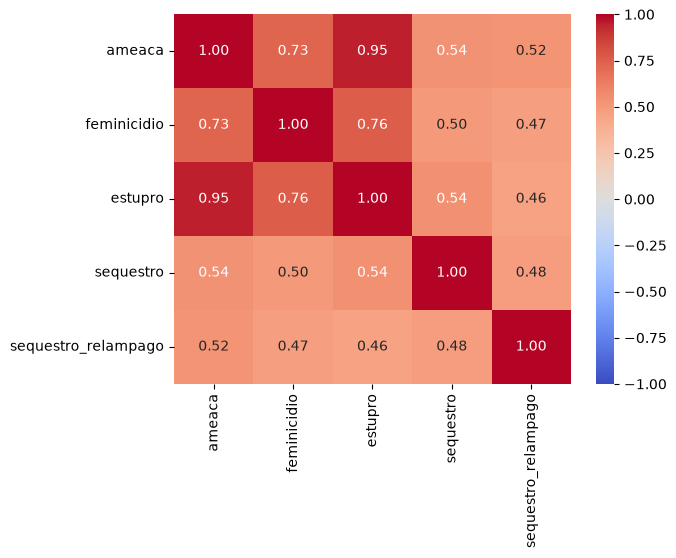

In [70]:
sns.heatmap(corr_pandas, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')

In [ ]:
df_sum = df.groupby('cisp')[['ameaca',
       'pessoas_desaparecidas', 'encontro_cadaver', 'encontro_ossada']].sum().reset_index().sort_values(by='cisp')
df_sum

In [66]:
corr_pandas = df_sum [['ameaca','pessoas_desaparecidas', 'encontro_cadaver', 'encontro_ossada']].corr()
corr_pandas

,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada
ameaca,1.000000,0.932290,0.737977,0.529672
pessoas_desaparecidas,0.932290,1.000000,0.757590,0.462192
encontro_cadaver,0.737977,0.757590,1.000000,0.605249
encontro_ossada,0.529672,0.462192,0.605249,1.000000


In [ ]:
sns.heatmap(corr_pandas, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')

In [4]:
array_ameaca = np.array(df['ameaca'])

NameError: name 'df' is not defined

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(array_horas, array, color='red', edgecolor='black', s=80)
plt.title('Horas de Estudo vs. Nota')
plt.xlabel('Horas de Estudo')
plt.ylabel('Nota')
plt.show()